## CIFAR-10 posterior-concentration diagnostics

This companion notebook checks the posterior-concentration picture directly on CIFAR-10. Along planted trajectories $x_t=(1-t)z+t x_\star$ it evaluates the exact empirical softmax and tracks five related-but-distinct collapse diagnostics — the planted mass $\lambda_\star$, the maximum mass $\lambda_{\max}$, the normalized posterior entropy $H(\lambda)/\log n$, the velocity alignment $\cos_t$, and the planted recovery rate $\mathbb P(\arg\max_i\lambda_i=i_\star)$ — overlaying the isotropic threshold $t_C^{\mathrm{iso}}$ and the covariance-corrected threshold $t_C^{\mathrm{cov}}$. The notebook below defines each diagnostic, explains why they must be read together rather than in isolation, and reports what the empirical transition looks like against these thresholds.


In [1]:
# =============================================================================
# Imports and configuration
# =============================================================================
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit, logsumexp


def find_project_root(start: Path | None = None) -> Path:
    """Return the closest ancestor directory containing pyproject.toml."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return current


# Anchor every path to the project root so that the notebook writes to the same
# places whether it is run from notebooks/, from the project root, or by Quarto.
PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'posterior_concentration'
OUTPUT_DIR = PROJECT_ROOT / 'output'
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# torchvision reads the CIFAR-10 pickles through a numpy call deprecated in numpy 2.4.
# The warning is third-party noise and prints an absolute local path into the output.
warnings.filterwarnings('ignore', message=r'dtype\(\): align should be passed as')

np.set_printoptions(precision=6, suppress=True)


The CIFAR-10 proxy parameters are

$$
d = 3\times 32\times 32 = 3072,
\qquad
n = 50,000,
\qquad
\sigma^2 \approx 0.24.
$$

The value of $\sigma^2$ is the per-coordinate variance after the standard transformation from pixels in $[0,1]$ to pixels in $[-1,1]$.


In [2]:
CIFAR10_D = 3 * 32 * 32
CIFAR10_N_FULL = 50_000
CIFAR10_SIGMA2 = 0.24
CIFAR10_ALPHA_FULL = np.log(CIFAR10_N_FULL) / CIFAR10_D

print(f'd = {CIFAR10_D}')
print(f'n = {CIFAR10_N_FULL}')
print(f'sigma^2 = {CIFAR10_SIGMA2:.4f}')
print(f'alpha = log(n)/d = {CIFAR10_ALPHA_FULL:.6f}')


d = 3072
n = 50000
sigma^2 = 0.2400
alpha = log(n)/d = 0.003522


### Posterior-decoding theory

The helpers below implement the isotropic threshold derived in the post: the information rate $\mathcal I_{\rm iso}(t)=\frac12\log(1+\sigma^2r(t)^2)$ with $r(t)=t/(1-t)$, the collapse time solving $\mathcal I_{\rm iso}(t_C)=\log n/d$, and the finite-$d$ logistic approximation to the planted mass.


In [3]:
# =============================================================================
# Posterior-decoding theory functions
# =============================================================================

def alpha_from_n_d(n: int, d: int) -> float:
    """Return alpha = log(n) / d in nats per dimension."""
    if n <= 0 or d <= 0:
        raise ValueError('n and d must be positive')
    return float(np.log(n) / d)


def r_from_t(t):
    """Map t in [0, 1) to r = t / (1 - t). Supports scalars and arrays."""
    t_arr = np.asarray(t, dtype=float)
    if np.any(t_arr < 0) or np.any(t_arr >= 1):
        raise ValueError('t must belong to [0, 1)')
    out = t_arr / (1.0 - t_arr)
    return float(out) if out.ndim == 0 else out


def t_from_r(r):
    """Map r >= 0 to t = r / (1 + r). Supports scalars and arrays."""
    r_arr = np.asarray(r, dtype=float)
    if np.any(r_arr < 0):
        raise ValueError('r must be nonnegative')
    out = r_arr / (1.0 + r_arr)
    return float(out) if out.ndim == 0 else out


def info_rate_isotropic(t, sigma2: float):
    """
    Isotropic Gaussian information rate:
        I_iso(t) = 0.5 * log(1 + sigma2 * r(t)^2).
    """
    if sigma2 <= 0:
        raise ValueError('sigma2 must be positive')
    r = r_from_t(t)
    return 0.5 * np.log1p(sigma2 * np.asarray(r) ** 2)


def collapse_time_isotropic(n: int, d: int, sigma2: float) -> float:
    """Closed-form isotropic posterior-decoding threshold."""
    alpha = alpha_from_n_d(n, d)
    r_c = np.sqrt(np.expm1(2.0 * alpha) / sigma2)
    return t_from_r(r_c)


def planted_mass_approx_from_info(info_rate, n: int, d: int):
    """
    Finite-d logistic approximation to the planted posterior mass.

    lambda_star(t) approx 1 / (1 + exp(d * (alpha - I(t))))
    """
    alpha = alpha_from_n_d(n, d)
    exponent = d * (alpha - np.asarray(info_rate, dtype=float))
    return expit(-exponent)


def planted_mass_approx_isotropic(t, n: int, d: int, sigma2: float):
    """Finite-d planted-mass approximation under the isotropic Gaussian proxy."""
    return planted_mass_approx_from_info(info_rate_isotropic(t, sigma2), n, d)


def time_for_planted_mass_isotropic(
    target_mass: float,
    n: int,
    d: int,
    sigma2: float,
) -> float:
    """Solve the isotropic logistic approximation for lambda_star approx target_mass."""
    if not 0 < target_mass < 1:
        raise ValueError('target_mass must lie in (0, 1)')
    alpha = alpha_from_n_d(n, d)
    required_info = alpha + np.log(target_mass / (1.0 - target_mass)) / d
    if required_info <= 0:
        return 0.0
    r = np.sqrt(np.expm1(2.0 * required_info) / sigma2)
    return t_from_r(r)


In [4]:
# CIFAR-10 isotropic proxy numbers

t_c_iso_full = collapse_time_isotropic(
    n=CIFAR10_N_FULL,
    d=CIFAR10_D,
    sigma2=CIFAR10_SIGMA2,
)

print(f'Isotropic posterior-decoding t_C: {t_c_iso_full:.6f}')
for mass in [0.5, 0.9, 0.99, 0.999]:
    t_mass = time_for_planted_mass_isotropic(
        target_mass=mass,
        n=CIFAR10_N_FULL,
        d=CIFAR10_D,
        sigma2=CIFAR10_SIGMA2,
    )
    print(f'Approximate t for lambda_star ~= {mass:>5}: {t_mass:.6f}')


Isotropic posterior-decoding t_C: 0.146482
Approximate t for lambda_star ~=   0.5: 0.146482
Approximate t for lambda_star ~=   0.9: 0.158469
Approximate t for lambda_star ~=  0.99: 0.170126
Approximate t for lambda_star ~= 0.999: 0.180274


The covariance-aware counterpart replaces $\mathcal I_{\rm iso}$ by $\mathcal I_C(t)=\frac{1}{2d}\sum_k\log(1+r(t)^2\mu_k)$, evaluated on the empirical eigenvalues $\mu_k$, and solves the same equation $\mathcal I_C(t_C)=\log n/d$.


In [5]:
# =============================================================================
# Covariance-aware posterior-decoding functions
# =============================================================================

def info_rate_covariance(t, eigenvalues: np.ndarray):
    """
    Covariance-aware information rate:
        I_C(t) = (1/(2d)) sum_k log(1 + r(t)^2 * mu_k).

    Supports scalar or array t. Eigenvalues should be nonnegative.
    """
    eigs = np.asarray(eigenvalues, dtype=float)
    if eigs.ndim != 1 or eigs.size == 0:
        raise ValueError('eigenvalues must be a nonempty one-dimensional array')
    if np.any(eigs < -1e-12):
        raise ValueError('eigenvalues must be nonnegative')
    eigs = np.maximum(eigs, 0.0)

    t_arr = np.asarray(t, dtype=float)
    scalar_input = t_arr.ndim == 0
    t_flat = np.atleast_1d(t_arr)
    r = r_from_t(t_flat)
    values = 0.5 * np.mean(np.log1p((r[:, None] ** 2) * eigs[None, :]), axis=1)
    return float(values[0]) if scalar_input else values.reshape(t_arr.shape)


def collapse_time_covariance(n: int, eigenvalues: np.ndarray) -> float:
    """Solve I_C(t) = log(n)/d using covariance eigenvalues."""
    eigs = np.asarray(eigenvalues, dtype=float)
    d = eigs.size
    alpha = alpha_from_n_d(n, d)

    if np.all(eigs <= 0):
        return np.nan

    def equation(t: float) -> float:
        return info_rate_covariance(t, eigs) - alpha

    # At t = 0, I_C = 0. As t -> 1, I_C -> infinity if at least one eigenvalue is positive.
    return float(brentq(equation, 1e-12, 1.0 - 1e-10, maxiter=200))


def planted_mass_approx_covariance(t, n: int, eigenvalues: np.ndarray):
    """Finite-d planted-mass approximation using the covariance-aware information rate."""
    d = len(eigenvalues)
    return planted_mass_approx_from_info(info_rate_covariance(t, eigenvalues), n, d)


### Theory plots

The next plot shows the isotropic information rate and the finite-dimensional planted-mass approximation for the CIFAR-10 proxy.


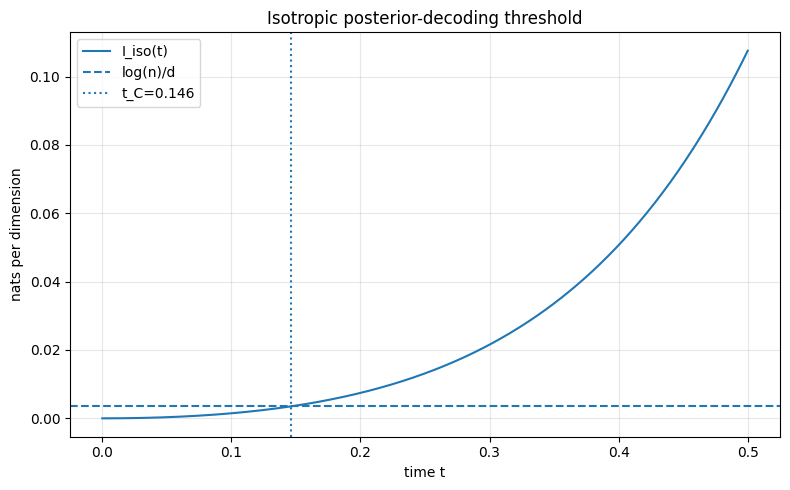

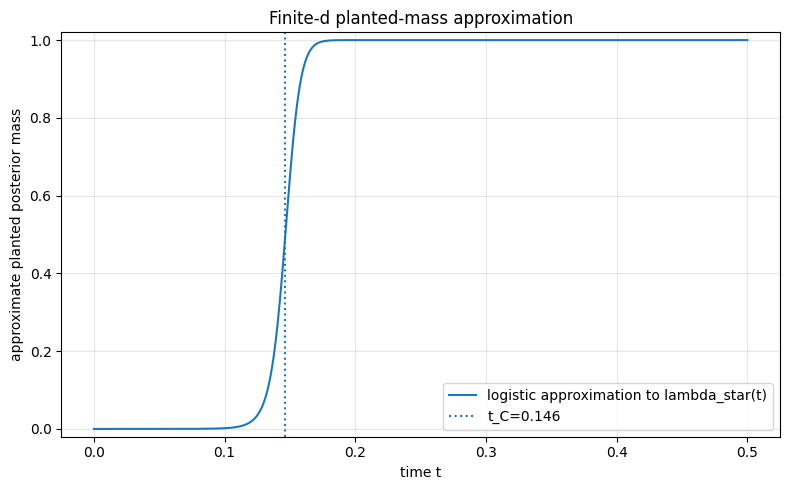

In [6]:
def plot_isotropic_theory(
    n: int = CIFAR10_N_FULL,
    d: int = CIFAR10_D,
    sigma2: float = CIFAR10_SIGMA2,
    t_max: float = 0.5,
    path: Path | None = FIGURES_DIR / 'posterior_isotropic_theory.png',
):
    """Plot the isotropic information rate and planted-mass approximation."""
    alpha = alpha_from_n_d(n, d)
    t_grid = np.linspace(0.0, t_max, 500)
    info = info_rate_isotropic(t_grid, sigma2)
    mass = planted_mass_approx_from_info(info, n, d)
    t_c = collapse_time_isotropic(n, d, sigma2)

    plt.figure(figsize=(8, 5))
    plt.plot(t_grid, info, label='I_iso(t)')
    plt.axhline(alpha, linestyle='--', label='log(n)/d')
    plt.axvline(t_c, linestyle=':', label=f't_C={t_c:.3f}')
    plt.xlabel('time t')
    plt.ylabel('nats per dimension')
    plt.title('Isotropic posterior-decoding threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(t_grid, mass, label='logistic approximation to lambda_star(t)')
    plt.axvline(t_c, linestyle=':', label=f't_C={t_c:.3f}')
    plt.xlabel('time t')
    plt.ylabel('approximate planted posterior mass')
    plt.title('Finite-d planted-mass approximation')
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if path is not None:
        mass_path = path.with_name(path.stem + '_planted_mass.png')
        plt.savefig(mass_path, dpi=160)
    plt.show()


plot_isotropic_theory()


### Softmax and velocity diagnostics

Along a planted trajectory we choose an index $i_\star$, draw $z\sim\mathcal N(0,I_d)$, and set

$$
x_t=(1-t)z+t x^{(i_\star)},
$$

so that the softmax $\lambda_i(x_t,t)$ is exactly the posterior over which training sample generated $x_t$. Collapse can be read off several *related but non-identical* quantities, so we track all of them together.

The first four are the concentration diagnostics named in the post:

$$
\lambda_\star(t)=\lambda_{i_\star}(x_t,t),
\qquad
\lambda_{\max}(t)=\max_i\lambda_i(x_t,t),
$$

$$
\frac{H(\lambda(t))}{\log n},
\qquad
\cos_t
=
\cos\left(u_t(x_t),\,x^{(i_\star)}-z\right),
$$

where the marginal velocity is the posterior-weighted average

$$
u_t(x_t)=\sum_i\lambda_i(x_t,t)\frac{x^{(i)}-x_t}{1-t}
=\frac{\sum_i\lambda_i(x_t,t)x^{(i)}-x_t}{1-t},
$$

and $\cos_t$ measures its alignment with the conditional velocity $x^{(i_\star)}-z$.

The fifth diagnostic is the **planted recovery rate**

$$
\mathbb P\left(\arg\max_i\lambda_i(x_t,t)=i_\star\right),
$$

the probability that the *top* softmax weight lands on the training image that actually generated the trajectory. We estimate it by Monte Carlo, as the fraction of planted trajectories whose $\arg\max_i\lambda_i$ equals $i_\star$ (in code, `np.mean(np.argmax(weights, axis=1) == planted_indices)`).

These five quantities are related but measure genuinely different events:

- $\lambda_\star\approx 1$ means the posterior concentrates **on the planted point**: true collapse.
- $\lambda_{\max}\approx 1$ means the posterior is one-hot, but possibly **on the wrong** nearest neighbour.
- low normalized entropy means the posterior is concentrated, but does not say **which** point wins.
- the planted recovery rate resolves exactly the ambiguity $\lambda_{\max}$ leaves open: it is high only when the one-hot mass sits on $i_\star$.
- high $\cos_t$ can occur **before** the posterior is literally one-hot, because the weighted-average velocity may already point almost along the conditional velocity.

This is why all five are plotted on the same axes below.


In [7]:
# =============================================================================
# Exact empirical softmax diagnostics
# =============================================================================

def rowwise_cosine(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Rowwise cosine similarity between two arrays of shape (batch, d)."""
    numerator = np.sum(a * b, axis=1)
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return numerator / np.maximum(denom, eps)


def softmax_weights_for_batch(
    x_t: np.ndarray,
    data: np.ndarray,
    t: float,
    data_norms: np.ndarray | None = None,
) -> np.ndarray:
    """
    Compute exact softmax weights for a batch of query points.

    Uses the posterior form with y = x_t / (1 - t) and r = t / (1 - t):
        logits_i = -0.5 * ||y - r x_i||^2.
    """
    if not 0 <= t < 1:
        raise ValueError('t must belong to [0, 1)')

    data64 = np.asarray(data, dtype=np.float64)
    x_t64 = np.atleast_2d(np.asarray(x_t, dtype=np.float64))
    n, d = data64.shape
    if x_t64.shape[1] != d:
        raise ValueError('x_t and data have incompatible dimensions')

    if data_norms is None:
        data_norms = np.sum(data64 * data64, axis=1)
    else:
        data_norms = np.asarray(data_norms, dtype=np.float64)

    r = r_from_t(t)
    y = x_t64 / (1.0 - t)
    y_norms = np.sum(y * y, axis=1)

    # ||y - r x_i||^2 = ||y||^2 + r^2 ||x_i||^2 - 2 r <y, x_i>
    dist2 = y_norms[:, None] + (r * r) * data_norms[None, :] - 2.0 * r * (y @ data64.T)
    logits = -0.5 * dist2
    log_probs = logits - logsumexp(logits, axis=1, keepdims=True)
    weights = np.exp(log_probs)
    return weights


def compute_diagnostics_at_t(
    data: np.ndarray,
    t: float,
    n_queries: int = 64,
    rng: np.random.Generator | None = None,
    data_norms: np.ndarray | None = None,
) -> dict[str, float]:
    """Compute empirical posterior and velocity diagnostics at a single time."""
    if rng is None:
        rng = np.random.default_rng(0)

    data = np.asarray(data, dtype=np.float64)
    n, d = data.shape
    if n_queries <= 0:
        raise ValueError('n_queries must be positive')

    planted_indices = rng.integers(0, n, size=n_queries)
    x_star = data[planted_indices]
    z = rng.standard_normal(size=(n_queries, d))
    x_t = (1.0 - t) * z + t * x_star

    weights = softmax_weights_for_batch(x_t, data, t, data_norms=data_norms)
    posterior_mean = weights @ data
    marginal_velocity = (posterior_mean - x_t) / (1.0 - t)
    conditional_velocity = x_star - z

    row = np.arange(n_queries)
    lambda_star = weights[row, planted_indices]
    lambda_max = np.max(weights, axis=1)
    entropy = -np.sum(weights * np.log(np.maximum(weights, 1e-300)), axis=1)
    normalized_entropy = entropy / np.log(n)
    cosine = rowwise_cosine(marginal_velocity, conditional_velocity)
    argmax_is_star = np.argmax(weights, axis=1) == planted_indices

    return {
        't': float(t),
        'lambda_star_mean': float(np.mean(lambda_star)),
        'lambda_star_std': float(np.std(lambda_star)),
        'lambda_max_mean': float(np.mean(lambda_max)),
        'lambda_max_std': float(np.std(lambda_max)),
        'entropy_norm_mean': float(np.mean(normalized_entropy)),
        'entropy_norm_std': float(np.std(normalized_entropy)),
        'cosine_mean': float(np.mean(cosine)),
        'cosine_std': float(np.std(cosine)),
        'argmax_is_star_mean': float(np.mean(argmax_is_star)),
    }


def compute_diagnostics_vs_time(
    data: np.ndarray,
    t_values: np.ndarray,
    n_queries: int = 64,
    seed: int = 0,
) -> pd.DataFrame:
    """Compute diagnostics over a grid of time values."""
    data = np.asarray(data, dtype=np.float64)
    data_norms = np.sum(data * data, axis=1)
    rng = np.random.default_rng(seed)
    records = []
    for t in np.asarray(t_values, dtype=float):
        records.append(
            compute_diagnostics_at_t(
                data=data,
                t=float(t),
                n_queries=n_queries,
                rng=rng,
                data_norms=data_norms,
            )
        )
    return pd.DataFrame.from_records(records)


def plot_diagnostic_curves(
    results: pd.DataFrame,
    n: int,
    d: int,
    sigma2: float | None = None,
    eigenvalues: np.ndarray | None = None,
    title: str = 'Posterior diagnostics',
    path: Path | None = None,
):
    """
    Plot the four empirical diagnostics advised in the post, plus the planted
    recovery rate, the finite-d planted-mass prediction, and the thresholds.
    """
    t_emp = np.asarray(results['t'], dtype=float)

    plt.figure(figsize=(9, 5.5))
    plt.plot(t_emp, results['lambda_star_mean'], label=r'$E[\lambda_\star]$')
    plt.plot(t_emp, results['lambda_max_mean'], label=r'$E[\lambda_{\max}]$')
    plt.plot(t_emp, results['entropy_norm_mean'], label=r'$E[H(\lambda)/\log n]$')
    plt.plot(t_emp, results['cosine_mean'], label=r'$E[\cos_t]$')

    # lambda_max can be one-hot on the wrong neighbour, so plot planted recovery
    # separately from lambda_max: the two only agree after the transition.
    if 'argmax_is_star_mean' in results:
        plt.plot(
            t_emp,
            results['argmax_is_star_mean'],
            linestyle=(0, (3, 1, 1, 1)),
            color='0.35',
            label=r'$P(\arg\max_i \lambda_i = i_\star)$',
        )

    # Finite-d theory prediction for the planted mass, overlaid on its empirical
    # counterpart: lambda_star(t) ~= 1 / (1 + exp(d * (alpha - I(t)))).
    t_grid = np.linspace(t_emp.min(), t_emp.max(), 400)
    if sigma2 is not None:
        plt.plot(
            t_grid,
            planted_mass_approx_isotropic(t_grid, n=n, d=d, sigma2=sigma2),
            linestyle='--',
            linewidth=1.2,
            color='C0',
            alpha=0.75,
            label=r'isotropic theory $\lambda_\star(t)$',
        )
        t_c = collapse_time_isotropic(n=n, d=d, sigma2=sigma2)
        plt.axvline(t_c, linestyle=':', color='C0', label=f'isotropic $t_C$={t_c:.3f}')

    if eigenvalues is not None:
        plt.plot(
            t_grid,
            planted_mass_approx_covariance(t_grid, n=n, eigenvalues=eigenvalues),
            linestyle='--',
            linewidth=1.2,
            color='C3',
            alpha=0.75,
            label=r'covariance theory $\lambda_\star(t)$',
        )
        t_c_cov = collapse_time_covariance(n=n, eigenvalues=eigenvalues)
        plt.axvline(t_c_cov, linestyle='-.', color='C3', label=f'covariance $t_C$={t_c_cov:.3f}')

    plt.xlabel('time t')
    plt.ylabel('diagnostic value')
    plt.title(title)
    plt.ylim(-0.05, 1.05)
    plt.legend(fontsize=8, loc='center right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=160)
    plt.show()


### Small Gaussian sanity check

This section runs without CIFAR-10. It verifies the mechanics of the posterior diagnostics on a smaller Gaussian codebook. The dimension and sample size are intentionally small so that the notebook executes quickly.

This plot is a computational sanity check, not a CIFAR-10 prediction.


Synthetic demo: n=800, d=128, sigma^2=0.24
Synthetic isotropic threshold t_C=0.4038


,t,lambda_star_mean,lambda_star_std,lambda_max_mean,lambda_max_std,entropy_norm_mean,entropy_norm_std,cosine_mean,cosine_std,argmax_is_star_mean
0,0.000,0.001250,0.000000,0.001250,0.000000,1.000000,0.000000,0.895992,0.018711,0.00000
1,0.025,0.001312,0.000189,0.001940,0.000098,0.998459,0.000137,0.893258,0.015023,0.03125
2,0.050,0.001333,0.000351,0.003030,0.000272,0.993773,0.000721,0.884116,0.021570,0.00000
3,0.075,0.001394,0.000538,0.004876,0.001029,0.984858,0.001601,0.881000,0.014680,0.00000
4,0.100,0.001679,0.001042,0.007469,0.002044,0.971488,0.004881,0.872208,0.018751,0.00000


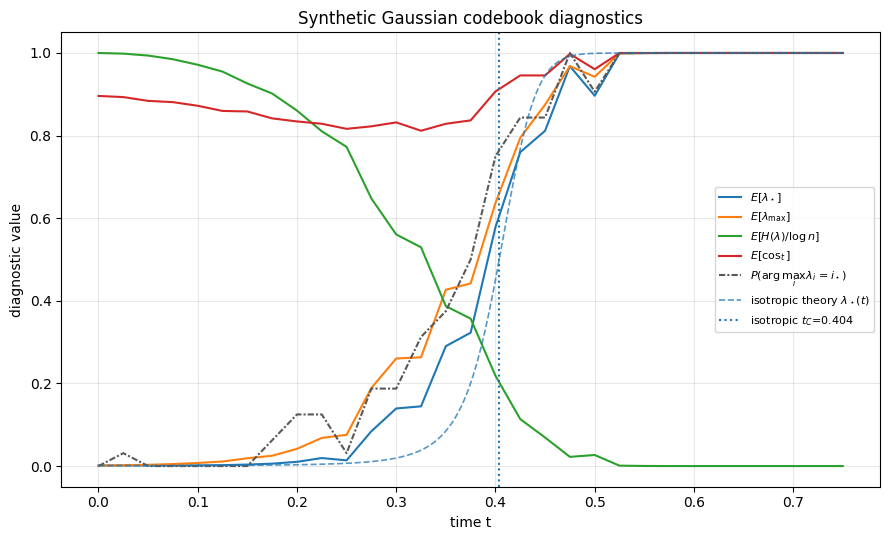

In [8]:
# =============================================================================
# Small synthetic sanity check
# =============================================================================

RUN_GAUSSIAN_SANITY_CHECK = True

if RUN_GAUSSIAN_SANITY_CHECK:
    rng = np.random.default_rng(123)
    d_demo = 128
    n_demo = 800
    sigma2_demo = 0.24
    data_demo = rng.normal(loc=0.0, scale=np.sqrt(sigma2_demo), size=(n_demo, d_demo))

    t_c_demo = collapse_time_isotropic(n=n_demo, d=d_demo, sigma2=sigma2_demo)
    print(f'Synthetic demo: n={n_demo}, d={d_demo}, sigma^2={sigma2_demo}')
    print(f'Synthetic isotropic threshold t_C={t_c_demo:.4f}')

    t_values_demo = np.linspace(0.0, 0.75, 31)
    demo_results = compute_diagnostics_vs_time(
        data=data_demo,
        t_values=t_values_demo,
        n_queries=32,
        seed=2026,
    )
    display(demo_results.head())

    plot_diagnostic_curves(
        results=demo_results,
        n=n_demo,
        d=d_demo,
        sigma2=sigma2_demo,
        title='Synthetic Gaussian codebook diagnostics',
        path=FIGURES_DIR / 'synthetic_posterior_diagnostics.png',
    )


In [9]:
# =============================================================================
# CIFAR-10 loader and covariance utilities
# =============================================================================

def load_cifar10_data_numpy(
    n_samples: int | None = None,
    root: str | Path = DATA_DIR,
    download: bool = False,
    random_subset: bool = False,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Load CIFAR-10 training data with the standard normalization used in the post.

    Set download=True on first use if the dataset is not already in `root`.

    Returns
    -------
    data : ndarray, shape (n_samples, 3072)
        Flattened images after ToTensor() and Normalize((0.5,...),(0.5,...)).
    labels : ndarray, shape (n_samples,)
        CIFAR-10 labels.
    """
    try:
        from torchvision import datasets, transforms
    except Exception as exc:
        raise RuntimeError(
            'Could not import torchvision. Install compatible versions, '
            'or run this notebook in an environment where CIFAR-10 can be loaded.'
        ) from exc

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    dataset = datasets.CIFAR10(
        root=str(root),
        train=True,
        download=download,
        transform=transform,
    )

    n_total = len(dataset)
    if n_samples is None:
        indices = np.arange(n_total)
    else:
        n_samples = min(int(n_samples), n_total)
        if random_subset:
            rng = np.random.default_rng(seed)
            indices = rng.choice(n_total, size=n_samples, replace=False)
        else:
            indices = np.arange(n_samples)

    data = np.empty((len(indices), 3 * 32 * 32), dtype=np.float32)
    labels = np.empty(len(indices), dtype=np.int64)

    for k, idx in enumerate(indices):
        image, label = dataset[int(idx)]
        data[k] = image.reshape(-1).detach().cpu().numpy()
        labels[k] = int(label)

    return data, labels


def compute_covariance_eigenvalues(data: np.ndarray, center: bool = True) -> np.ndarray:
    """Compute eigenvalues of the empirical covariance matrix of flattened data."""
    X = np.asarray(data, dtype=np.float64)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    n = X.shape[0]
    covariance = (X.T @ X) / n
    eigs = np.linalg.eigvalsh(covariance)
    eigs = np.maximum(eigs, 0.0)
    return np.sort(eigs)[::-1]


def load_or_compute_covariance_eigenvalues(
    data: np.ndarray,
    path: str | Path = OUTPUT_DIR / 'cifar10_cov_eigs.npy',
    force: bool = False,
) -> np.ndarray:
    """Load covariance eigenvalues from disk when available; otherwise compute and save."""
    path = Path(path)
    if path.exists() and not force:
        if path.suffix == '.npy':
            return np.load(path)
        return np.loadtxt(path)

    eigs = compute_covariance_eigenvalues(data)
    path.parent.mkdir(exist_ok=True, parents=True)
    if path.suffix == '.npy':
        np.save(path, eigs)
    else:
        np.savetxt(path, eigs)
    return eigs


def plot_covariance_spectrum(
    eigenvalues: np.ndarray,
    path: Path | None = FIGURES_DIR / 'eigenvalues-cifar10.png',
):
    """Plot the empirical covariance eigenvalue spectrum."""
    eigs = np.asarray(eigenvalues, dtype=float)

    plt.figure(figsize=(8, 5))
    plt.plot(eigs)
    plt.yscale('log')
    plt.xlabel('eigenvalue index')
    plt.ylabel('eigenvalue, log scale')
    plt.title('CIFAR-10 covariance eigenvalue spectrum')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=160)
    plt.show()


def plot_information_rate_with_covariance(
    n: int,
    sigma2: float,
    eigenvalues: np.ndarray,
    t_max: float = 0.8,
    path: Path | None = FIGURES_DIR / 'posterior_information_rate_covariance.png',
):
    """Plot isotropic and covariance-aware information rates against log(n)/d."""
    eigs = np.asarray(eigenvalues, dtype=float)
    d = len(eigs)
    alpha = alpha_from_n_d(n, d)
    t_grid = np.linspace(0.0, t_max, 600)
    info_iso = info_rate_isotropic(t_grid, sigma2=sigma2)
    info_cov = info_rate_covariance(t_grid, eigs)
    t_c_iso = collapse_time_isotropic(n=n, d=d, sigma2=sigma2)
    t_c_cov = collapse_time_covariance(n=n, eigenvalues=eigs)

    plt.figure(figsize=(8, 5))
    plt.plot(t_grid, info_iso, label='isotropic I_iso(t)')
    plt.plot(t_grid, info_cov, label='covariance I_C(t)')
    plt.axhline(alpha, linestyle='--', label='log(n)/d')
    plt.axvline(t_c_iso, linestyle=':', label=f'isotropic t_C={t_c_iso:.3f}')
    plt.axvline(t_c_cov, linestyle='-.', label=f'covariance t_C={t_c_cov:.3f}')
    plt.xlabel('time t')
    plt.ylabel('nats per dimension')
    plt.title('Posterior-decoding threshold with empirical covariance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=160)
    plt.show()


### CIFAR-10 data and covariance-aware threshold

The cell below computes the empirical covariance eigenvalues of all 50,000 images, then solves the log-determinant threshold

$$
\log n = \frac12\log\det\left(I_d+r_C^2 C\right).
$$

The eigenvalues are cached, so the eigendecomposition runs only once. They are computed before the diagnostics below so that both the isotropic and the covariance-aware thresholds can be overlaid on the empirical curves.


Loaded CIFAR-10: n=50000, d=3072
Empirical average per-coordinate variance: 0.247917
Post proxy value for comparison:           0.24



Covariance eigenvalues: 3072
Mean eigenvalue: 0.247918
Max eigenvalue:  221.448869
Min eigenvalue:  6.348635e-06


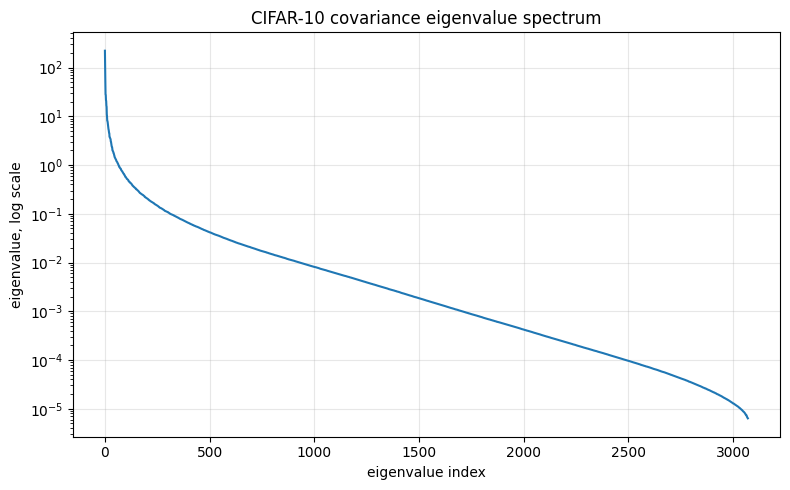

Covariance-aware t_C, full CIFAR-10 n=50,000: 0.178817
Isotropic t_C for comparison:                 0.146482


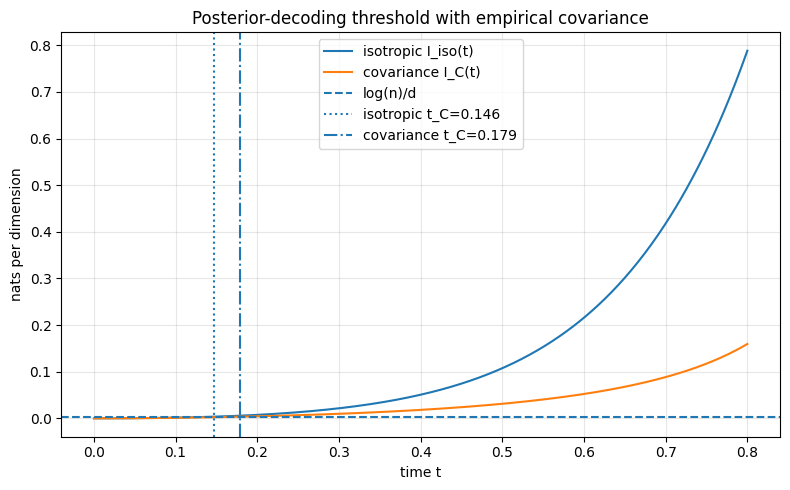

In [10]:
# =============================================================================
# CIFAR-10 data and covariance-aware threshold
# =============================================================================

RUN_CIFAR10 = True

if RUN_CIFAR10:
    # Load the training set once; the diagnostics cell below reuses this array.
    data_cifar, labels_cifar = load_cifar10_data_numpy(n_samples=None)
    n_cifar, d_cifar = data_cifar.shape
    sigma2_empirical = float(np.mean(np.var(data_cifar, axis=0)))

    print(f'Loaded CIFAR-10: n={n_cifar}, d={d_cifar}')
    print(f'Empirical average per-coordinate variance: {sigma2_empirical:.6f}')
    print(f'Post proxy value for comparison:           {CIFAR10_SIGMA2}')

    eigs_cifar = load_or_compute_covariance_eigenvalues(
        data_cifar,
        path=OUTPUT_DIR / 'cifar10_cov_eigs.npy',
        force=False,
    )

    print(f'\nCovariance eigenvalues: {len(eigs_cifar)}')
    print(f'Mean eigenvalue: {np.mean(eigs_cifar):.6f}')
    print(f'Max eigenvalue:  {np.max(eigs_cifar):.6f}')
    print(f'Min eigenvalue:  {np.min(eigs_cifar):.6e}')

    plot_covariance_spectrum(eigs_cifar)

    t_c_cov_full = collapse_time_covariance(CIFAR10_N_FULL, eigs_cifar)
    print(f'Covariance-aware t_C, full CIFAR-10 n=50,000: {t_c_cov_full:.6f}')
    print(f'Isotropic t_C for comparison:                 {t_c_iso_full:.6f}')

    plot_information_rate_with_covariance(
        n=CIFAR10_N_FULL,
        sigma2=CIFAR10_SIGMA2,
        eigenvalues=eigs_cifar,
        t_max=0.8,
        path=FIGURES_DIR / 'posterior_information_rate_covariance.png',
    )
else:
    print('CIFAR-10 sections skipped. Set RUN_CIFAR10 = True to run them.')


### CIFAR-10 diagnostics

This cell computes the exact empirical softmax diagnostics on CIFAR-10. Both theory curves are overlaid: the isotropic proxy and the covariance-aware log-determinant threshold.


Softmax codebook: n=50000, d=3072
Using alpha=log(50000)/3072=0.003522
Isotropic threshold for this codebook: 0.144465


,t,lambda_star_mean,lambda_star_std,lambda_max_mean,lambda_max_std,entropy_norm_mean,entropy_norm_std,cosine_mean,cosine_std,argmax_is_star_mean
0,0.0000,0.000020,0.000000,0.000020,0.000000,1.000000,0.000000,0.900133,0.045172,0.0
1,0.0125,0.000021,0.000007,0.000091,0.000023,0.993833,0.003423,0.901565,0.045803,0.0
2,0.0250,0.000032,0.000026,0.000307,0.000132,0.978833,0.007494,0.897197,0.042360,0.0
3,0.0375,0.000056,0.000076,0.001165,0.000806,0.949366,0.017736,0.905228,0.039139,0.0
4,0.0500,0.000101,0.000129,0.003284,0.002002,0.906821,0.026961,0.906075,0.036316,0.0


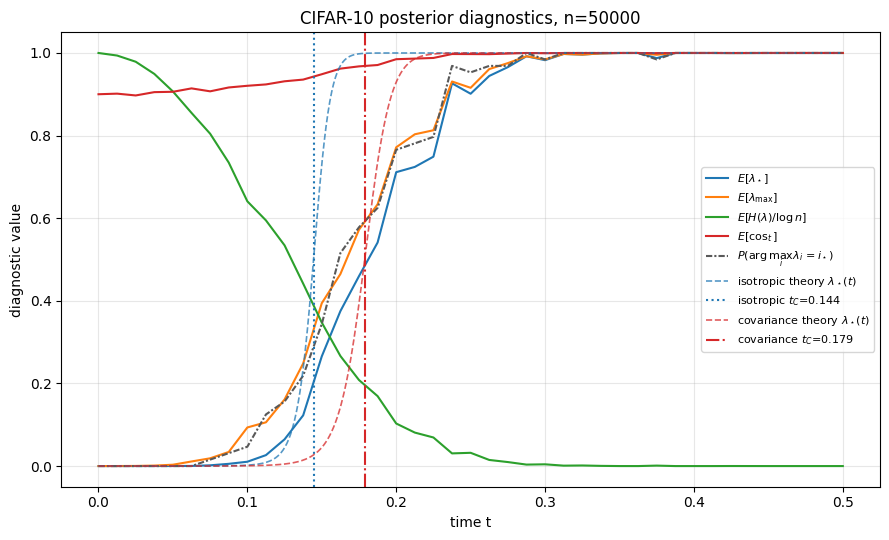

In [11]:
# =============================================================================
# CIFAR-10 empirical diagnostics
# =============================================================================

# Number of planted trajectories averaged at each time.
N_QUERY_TRAJECTORIES = 64
CIFAR10_T_VALUES = np.linspace(0.0, 0.5, 41)

# Set to an int (e.g. 1000) to restrict the softmax codebook for a fast test.
# The theory overlay follows automatically through log(n)/d.
CIFAR10_N_FOR_SOFTMAX = None

if RUN_CIFAR10:
    if CIFAR10_N_FOR_SOFTMAX is None:
        data_softmax = data_cifar
    else:
        data_softmax = data_cifar[:CIFAR10_N_FOR_SOFTMAX]

    n_softmax, d_softmax = data_softmax.shape
    sigma2_softmax = float(np.mean(np.var(data_softmax, axis=0)))

    print(f'Softmax codebook: n={n_softmax}, d={d_softmax}')
    print(f'Using alpha=log({n_softmax})/{d_softmax}={alpha_from_n_d(n_softmax, d_softmax):.6f}')
    print(
        'Isotropic threshold for this codebook: '
        f'{collapse_time_isotropic(n_softmax, d_softmax, sigma2_softmax):.6f}'
    )

    cifar_results = compute_diagnostics_vs_time(
        data=data_softmax,
        t_values=CIFAR10_T_VALUES,
        n_queries=N_QUERY_TRAJECTORIES,
        seed=2026,
    )
    display(cifar_results.head())

    cifar_results.to_csv(OUTPUT_DIR / 'cifar10_posterior_diagnostics.csv', index=False)

    # Overlay both thresholds: the eigenvalues describe the same codebook only
    # when the full training set is used.
    plot_diagnostic_curves(
        results=cifar_results,
        n=n_softmax,
        d=d_softmax,
        sigma2=sigma2_softmax,
        eigenvalues=eigs_cifar if n_softmax == CIFAR10_N_FULL else None,
        title=f'CIFAR-10 posterior diagnostics, n={n_softmax}',
        path=FIGURES_DIR / 'cifar10_posterior_diagnostics.png',
    )
else:
    print('CIFAR-10 empirical diagnostics skipped. Set RUN_CIFAR10 = True to run them.')


**Observations.**

The posterior transition is sharp and lands where the theory says it should. The normalized entropy falls from $1$ to nearly $0$ between $t\approx 0.10$ and $t\approx 0.30$, and $\mathbb E[\lambda_\star]$ crosses $1/2$ at $t\approx 0.18$. The isotropic proxy predicts $t_C\approx 0.146$ and the covariance-aware log-determinant threshold predicts $t_C\approx 0.179$; the anisotropic formula is the more accurate of the two, which is expected given how spiked the CIFAR-10 spectrum is. The isotropic value is the cruder prediction, but it already recovers the right early-time scale from the single number $\sigma^2$.

The three concentration diagnostics separate exactly as the post anticipates. Around $t\approx 0.15$, $\mathbb E[\lambda_{\max}]\approx 0.39$ while $\mathbb E[\lambda_\star]\approx 0.27$ and the planted recovery rate is only $\approx 0.34$. The softmax is already concentrating there, but on the wrong training image about two thirds of the time. Reading $\lambda_{\max}$ alone would place the collapse earlier than genuine planted recovery occurs.

The cosine alignment behaves differently from the other three, and is the weakest diagnostic at small $t$. It does not start near zero: it sits at $\approx 0.90$ at $t=0$ and increases monotonically. The reason is structural rather than numerical. At small $t$ the interpolant is $x_t\approx z$, so the marginal velocity is $\approx\bar x-z$ while the conditional velocity is $x_\star-z$. Both are dominated by the same $-z$ term, and since $\|z\|\approx\sqrt d\approx 55$ is large compared with $\|x_\star\|\approx\sqrt{d\sigma^2}\approx 28$, the two vectors are nearly parallel before any posterior concentration has taken place. This is the concrete version of the caveat in the post that high cosine similarity can precede a one-hot posterior, so $\cos_t$ should not be read as a collapse indicator on its own. It is also worth keeping in mind when reading the cosine-similarity histograms reproduced earlier in the post: part of the alignment they show at small $t$ is high-dimensional geometry rather than posterior concentration.


### Summary table

The table collects the theoretical thresholds alongside the times actually measured on CIFAR-10, so the Gaussian-proxy prediction can be compared directly against the empirical transition.


In [12]:
def first_crossing(t_values: np.ndarray, values: np.ndarray, level: float) -> float:
    """First time at which `values` reaches `level`, by linear interpolation."""
    t_values = np.asarray(t_values, dtype=float)
    values = np.asarray(values, dtype=float)
    above = np.flatnonzero(values >= level)
    if above.size == 0:
        return float('nan')
    k = int(above[0])
    if k == 0:
        return float(t_values[0])
    v0, v1 = values[k - 1], values[k]
    if v1 == v0:
        return float(t_values[k])
    weight = (level - v0) / (v1 - v0)
    return float(t_values[k - 1] + weight * (t_values[k] - t_values[k - 1]))


rows = [
    {'quantity': 'alpha = log(50000)/3072', 'value': CIFAR10_ALPHA_FULL},
    {'quantity': 'isotropic t_C, sigma^2=0.24 (theory)', 'value': t_c_iso_full},
    {
        'quantity': 'isotropic t for lambda_star approx 0.9 (theory)',
        'value': time_for_planted_mass_isotropic(0.9, CIFAR10_N_FULL, CIFAR10_D, CIFAR10_SIGMA2),
    },
    {
        'quantity': 'isotropic t for lambda_star approx 0.99 (theory)',
        'value': time_for_planted_mass_isotropic(0.99, CIFAR10_N_FULL, CIFAR10_D, CIFAR10_SIGMA2),
    },
]

if 't_c_cov_full' in globals():
    rows.append({'quantity': 'covariance t_C, empirical spectrum (theory)', 'value': t_c_cov_full})

if 'cifar_results' in globals():
    # cos_t is already near 0.9 at t=0 because both velocities are dominated by
    # the shared -z term, so it is only informative at a stricter level.
    rows += [
        {
            'quantity': 'CIFAR-10 t where E[lambda_star] reaches 0.5 (measured)',
            'value': first_crossing(cifar_results['t'], cifar_results['lambda_star_mean'], 0.5),
        },
        {
            'quantity': 'CIFAR-10 t where planted recovery reaches 0.5 (measured)',
            'value': first_crossing(cifar_results['t'], cifar_results['argmax_is_star_mean'], 0.5),
        },
        {
            'quantity': 'CIFAR-10 t where E[H/log n] falls to 0.5 (measured)',
            'value': first_crossing(
                cifar_results['t'], -np.asarray(cifar_results['entropy_norm_mean']), -0.5
            ),
        },
        {
            'quantity': 'CIFAR-10 E[cos_t] at t=0 (measured, floor)',
            'value': float(cifar_results['cosine_mean'].iloc[0]),
        },
        {
            'quantity': 'CIFAR-10 t where E[cos_t] reaches 0.99 (measured)',
            'value': first_crossing(cifar_results['t'], cifar_results['cosine_mean'], 0.99),
        },
    ]

summary = pd.DataFrame(rows)
summary


,quantity,value
0,alpha = log(50000)/3072,0.003522
1,"isotropic t_C, sigma^2=0.24 (theory)",0.146482
2,isotropic t for lambda_star approx 0.9 (theory),0.158469
3,isotropic t for lambda_star approx 0.99 (theory),0.170126
4,"covariance t_C, empirical spectrum (theory)",0.178817
5,CIFAR-10 t where E[lambda_star] reaches 0.5 (m...,0.181172
6,CIFAR-10 t where planted recovery reaches 0.5 ...,0.161364
7,CIFAR-10 t where E[H/log n] falls to 0.5 (meas...,0.129633
8,"CIFAR-10 E[cos_t] at t=0 (measured, floor)",0.900133
9,CIFAR-10 t where E[cos_t] reaches 0.99 (measured),0.227669
